Imports required:

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Creation of two bar plots - the first will visualise the average IMD rank for the North, Midlands and South of England, whilst the second will visualise the crime rates, per offense group, by location category (North, Midlands and South of England).

North will encompass ITL1: 'North East', 'North West', 'Yorkshire and the Humber'
Midlands will encompass ITL1: 'East Midlands', 'West Midlands'
South will encompass ITL1: 'East', 'London', 'South East', 'South West'

IMD Rank - North, Midlands and South of England

In [ ]:


# plt.show()

Crime rates, by offense group - North, Midlands and South of England

,Unnamed: 0,Financial Year,Financial Quarter,Force Name,Offence Description,Offence Group,Offence Subgroup,Offence Code,Number of Offences,ITL1 region,ITL2 region
0,0,2024/25,1,Avon and Somerset,Absconding from lawful custody,Miscellaneous crimes against society,Miscellaneous crimes against society,80,2,South West (England),"['West of England', 'North Somerset, Somerset ..."
1,1,2024/25,1,Avon and Somerset,Abuse of children through sexual exploitation,Sexual offences,Other sexual offences,71,4,South West (England),"['West of England', 'North Somerset, Somerset ..."


,Unnamed: 0,Financial Year,Financial Quarter,Force Name,Offence Description,Offence Group,Offence Subgroup,Offence Code,Number of Offences,Geographic Region,ITL2 region
0,0,2024/25,1,Avon and Somerset,Absconding from lawful custody,Miscellaneous crimes against society,Miscellaneous crimes against society,80,2,South,"['West of England', 'North Somerset, Somerset ..."
1,1,2024/25,1,Avon and Somerset,Abuse of children through sexual exploitation,Sexual offences,Other sexual offences,71,4,South,"['West of England', 'North Somerset, Somerset ..."


Geographic Region  Offence Group                       
Midlands           Criminal damage and arson                80527
                   Drug offences                            28293
                   Miscellaneous crimes against society     21227
                   Possession of weapons offences           13588
                   Public order offences                    72502
                   Robbery                                  12110
                   Sexual offences                          38424
                   Theft offences                          284991
                   Violence against the person             355565
North              Criminal damage and arson               145917
                   Drug offences                            64740
                   Miscellaneous crimes against society     44179
                   Possession of weapons offences           17291
                   Public order offences                   148156
                   R

count        27.000000
mean     183943.666667
std      253561.550829
min       12110.000000
25%       33358.500000
50%       72502.000000
75%      195993.000000
max      963184.000000
Name: Number of Offences, dtype: float64

<class 'pandas.Series'>
<class 'pandas.DataFrame'>


,Geographic Region,Offence Group,Number of Offences
0,Midlands,Criminal damage and arson,80527
1,Midlands,Drug offences,28293
2,Midlands,Miscellaneous crimes against society,21227
3,Midlands,Possession of weapons offences,13588
4,Midlands,Public order offences,72502


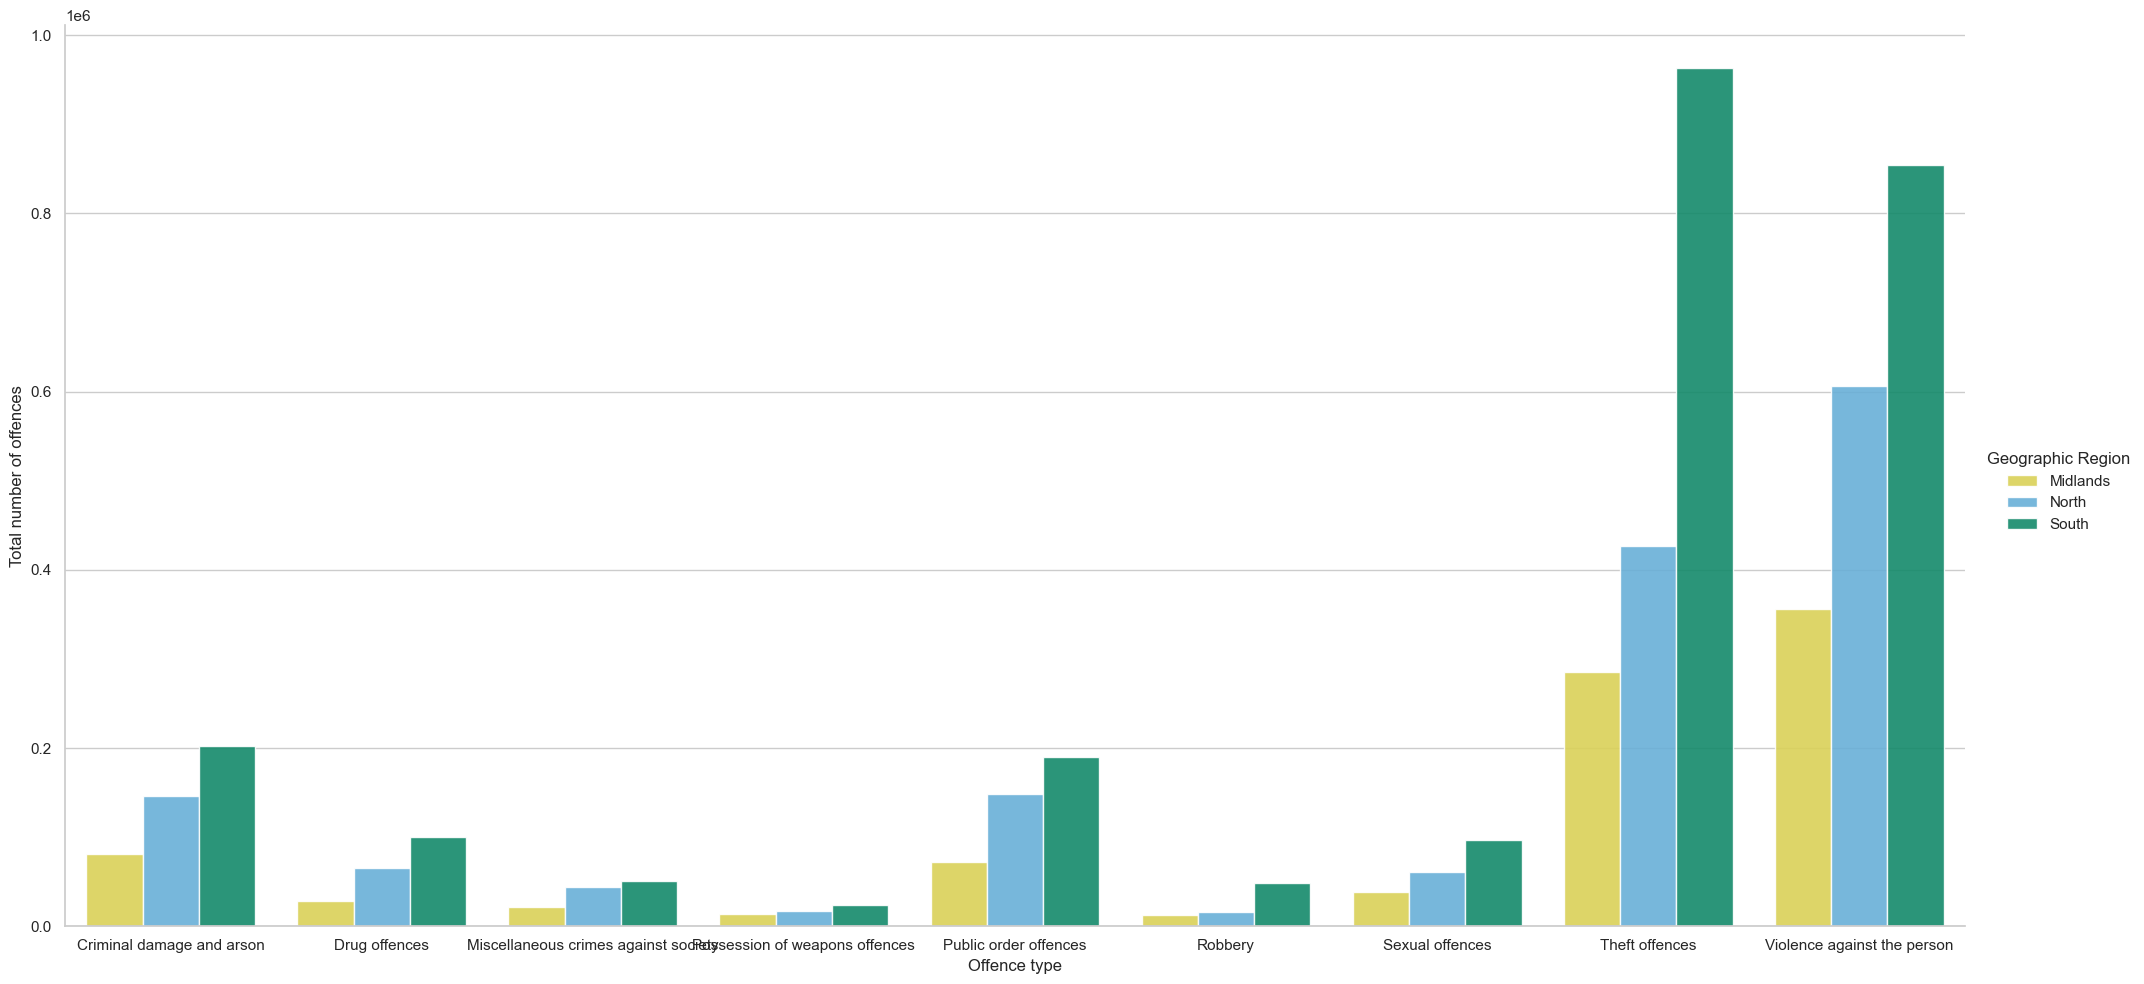

In [77]:
crime_df = pd.read_csv('CLEANED-regional_forces_crime_data_2024-2025.csv')

# Visually checking the head of the data
display(crime_df.head(2))

# Renaming ITL1 regions and grouping into North, Midlands or South
crime_df_v2 = crime_df.replace({'North East (England)': 'North', 'North West (England)': 'North',\
                                'Yorkshire and The Humber': 'North', 'East Midlands': 'Midlands',\
                               'West Midlands': 'Midlands', 'East (England)': 'South', 'London':'South',\
                               'South East (England)':'South', 'South West (England)': 'South'}, inplace=True)
crime_df_v2.rename(columns={'ITL1 region': 'Geographic Region'}, inplace=True)

# Check changes have been made correctly
display(crime_df_v2.head(2))

# Preparing/grouping the dataset, as required for the following graph
crime_s = crime_df_v2.groupby(['Geographic Region', 'Offence Group'])['Number of Offences'].sum()
display(crime_s.head(20))

# Descriptive statistics for the number of offenses in England
display(crime_s.describe())

# To note: the .groupby() function has changed the df to a series
# Need to convert back to a df, to then use the seaborn .catplot() function
print(type(crime_s))
crime_df_v3 = crime_s.reset_index()
print(type(crime_df_v3))
display(crime_df_v3.head(5))

#Creating the graph
sns.set_theme(style='whitegrid')

# One of the best coluor palettes for colour blindness is 'okabeito'

okabeito = ['#F0E442', '#56B4E9', '#009E73',\
           '#E69F00', '#0072B2', '#D55E00',\
           '#CC79A7']
sns.set_palette(okabeito)

crime_graph = sns.catplot(
                data=crime_df_v3, kind='bar',
                x='Offence Group', y='Number of Offences',
                hue='Geographic Region', alpha=0.9, 
                height=10, aspect=2
)

crime_graph.legend.set_title('')
crime_graph.set_axis_labels('Offence type', 'Total number of offences')

plt.show()